<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 24px 26px;">
<div style="width: 40px; height: 4px; background: #3498db; border-radius: 3px; margin-bottom: 12px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; font-size: 1.35em; font-weight: 700; color: #2c3e50;">מטרת המחברת</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; line-height: 1.8; color: #2c3e50;">מטרת המחברת היא לבנות מאגר נתונים מורחב, המכיל מגוון רחב יותר של מסמכים: מסמכים עם דרכונים שונים, מסמכים עם מקרי קצה, ומסמכים המכילים תצלום שאינו דרכון — קבלות פיקטיביות.</div>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0; line-height: 1.8; color: #2c3e50;">בניית המאגר נעשית בכמה שלבים. השלב הראשון הוא משיכת הנתונים: הדרכונים הפיקטיביים נלקחים מ-HuggingFace, והקבלות הפיקטיביות מ-Kaggle.</div>
</div>

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 24px 26px;">
<div style="width: 40px; height: 4px; background: #3498db; border-radius: 3px; margin-bottom: 12px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; font-size: 1.35em; font-weight: 700; color: #2c3e50;">משיכת הנתונים</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 10px 0; line-height: 1.8; color: #2c3e50;"><b>הקבלות</b> מורדות מ-Kaggle, מהמאגר <code style="direction: ltr; display: inline-block;">trainingdatapro/ocr-receipts-text-detection</code>, לתיקייה <code style="direction: ltr; display: inline-block;">negative_document</code>.</div>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; line-height: 1.8; color: #2c3e50;"><b>הדרכונים</b> מורדים משני מאגרים ב-HuggingFace — <code style="direction: ltr; display: inline-block;">aslessor/passports</code> ו-<code style="direction: ltr; display: inline-block;">UniqueData/generated-passports-segmentation</code> — לתיקייה <code style="direction: ltr; display: inline-block;">passport_standard</code>. שם כל קובץ מקבל קידומת לפי המאגר שממנו הגיע.</div>
<div style="direction: rtl !important; text-align: right !important; background: #f7fafc; border-right: 4px solid #3498db; border-radius: 8px; padding: 12px 16px;">
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">לפני כל הורדה נבדק אם התיקייה כבר מכילה תמונות, ואם כן ההורדה מדולגת. לכן ניתן להריץ את התא שוב מבלי להוריד את הכל מחדש.</div>
</div>
</div>

In [1]:
import os

os.environ["KAGGLE_USERNAME"] = "ester8840"
os.environ["KAGGLE_KEY"] = "9b2e3b866e86b2f357661750c4c99c30"

In [2]:
from pathlib import Path

import cv2
import numpy as np
from datasets import load_dataset
from kaggle.api.kaggle_api_extended import KaggleApi

RAW_DIR = Path("data/raw")
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif"}

api = KaggleApi()
api.authenticate()


def count_images(directory):
    """Count image files already present in a folder to skip redundant downloads."""
    if not directory.exists():
        return 0
    return sum(
        1 for path in directory.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )


def download_kaggle(dataset_slug, pool_name):
    """Download a Kaggle dataset into its respective subfolder."""
    short_name = dataset_slug.split("/")[-1]
    target = RAW_DIR / pool_name / short_name

    if count_images(target) > 0:
        print(f"  {short_name}: already exists, skipping...")
        return

    target.mkdir(parents=True, exist_ok=True)
    api.dataset_download_files(dataset_slug, path=str(target), unzip=True, quiet=True)
    print(f"  {short_name}: downloaded {count_images(target)} images successfully.")


def download_huggingface(repo_id, prefix, pool_name):
    """Save every image in a HuggingFace dataset into the pool folder."""
    target = RAW_DIR / pool_name
    target.mkdir(parents=True, exist_ok=True)

    dataset = load_dataset(repo_id, split="train")

    # Fail loudly rather than silently saving nothing if the column is named
    # something other than "image"
    if "image" not in dataset.column_names:
        raise KeyError(f"No 'image' column in {repo_id}: {dataset.column_names}")

    saved = 0
    for idx, item in enumerate(dataset):
        file_path = target / f"{prefix}_passport_{idx:04d}.jpg"
        if file_path.exists():
            continue

        image = item["image"]
        if isinstance(image, np.ndarray):
            cv2.imwrite(str(file_path), image)
        else:
            image.save(file_path)
        saved += 1

    print(f"    -> Added {saved} new images from '{repo_id}' (total: {count_images(target)})")


# --- Negatives: receipts from Kaggle -----------------------------------------

print("=== 1. Negative documents (Kaggle) ===")

NEGATIVE_KAGGLE = [
    "trainingdatapro/ocr-receipts-text-detection",
]

for slug in NEGATIVE_KAGGLE:
    try:
        download_kaggle(slug, "negative_document")
    except Exception as error:
        print(f"  {slug.split('/')[-1]}: FAILED — {error}")


# --- Positives: passports from HuggingFace -----------------------------------

print("\n=== 2. Passports (HuggingFace) ===")

HF_PASSPORT_DATASETS = [
    ("aslessor/passports", "aslessor"),
    ("UniqueData/generated-passports-segmentation", "uniquedata"),
]

for repo_id, prefix in HF_PASSPORT_DATASETS:
    print(f"  Loading '{repo_id}'...")
    try:
        download_huggingface(repo_id, prefix, "passport_standard")
    except Exception as error:
        print(f"    -> FAILED to load '{repo_id}': {error}")


print(f"\nPassports: {count_images(RAW_DIR / 'passport_standard')}")
print(f"Negatives: {count_images(RAW_DIR / 'negative_document')}")

=== 1. Negative documents (Kaggle) ===
Dataset URL: https://www.kaggle.com/datasets/trainingdatapro/ocr-receipts-text-detection
  ocr-receipts-text-detection: downloaded 40 images successfully.

=== 2. Passports (HuggingFace) ===
  Loading 'aslessor/passports'...


    -> Added 100 new images from 'aslessor/passports' (total: 100)
  Loading 'UniqueData/generated-passports-segmentation'...
    -> Added 22 new images from 'UniqueData/generated-passports-segmentation' (total: 122)

Passports: 122
Negatives: 40


<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 24px 26px;">
<div style="width: 40px; height: 4px; background: #3498db; border-radius: 3px; margin-bottom: 12px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; font-size: 1.35em; font-weight: 700; color: #2c3e50;">הגדרות לשלב הניקוי</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; line-height: 1.8; color: #2c3e50;">התא מגדיר את הנתיבים, את הספים שלפיהם נפסלות תמונות, ושלוש פונקציות עזר שישמשו בשלב הבא.</div>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 10px 0; line-height: 1.8; color: #2c3e50;"><b>הספים:</b> תמונות קטנות מ-200 פיקסלים נפסלות, שכן הטקסט בדרכון לא יהיה קריא לאחר הקטנה נוספת. סף הריקנוּת מבוסס על סטיית התקן של הפיקסלים, וסף הטשטוש על שונות אופרטור לפלס.</div>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0; line-height: 1.8; color: #2c3e50;"><b>הפונקציות:</b> אחת ממירה כל תמונה לשלושה ערוצי צבע, ושתיים מחשבות את ציוני הריקנוּת והחדות שלפיהם מתקבלת החלטת הפסילה.</div>
</div>

In [3]:
import hashlib
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

RAW_DIR = Path("data/raw")
CLEAN_DIR = Path("data/clean")
MANIFEST_PATH = Path("data/image_manifest.csv")

# Below this size the passport text is unreadable after augmentation
MIN_WIDTH, MIN_HEIGHT = 200, 200

# Pixel standard deviation below this means a uniform, contentless image
BLANK_STD_THRESHOLD = 5.0

# Laplacian variance below this means very few sharp edges, i.e. a blurry image
BLUR_THRESHOLD = 50.0

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

POOLS = {
    "passport_standard": {"source": "huggingface"},
    "negative_document": {"source": "kaggle"},
}

def normalise_channels(image):
    """Return a 3-channel BGR image, flattening any alpha onto a white background."""
    if image.ndim == 2:
        return cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    if image.shape[2] == 4:
        alpha = image[:, :, 3:4].astype(np.float32) / 255.0
        rgb = image[:, :, :3].astype(np.float32)
        return (rgb * alpha + 255.0 * (1 - alpha)).astype(np.uint8)

    if image.shape[2] == 3:
        return image

    return None

def blank_score(gray):
    """Pixel spread. A blank or single-coloured page scores near zero."""
    return float(gray.std())

def sharpness_score(gray):
    """Laplacian variance. Low values mean few sharp edges — a blurry image."""
    return float(cv2.Laplacian(gray, cv2.CV_64F).var())

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 24px 26px;">
<div style="width: 40px; height: 4px; background: #3498db; border-radius: 3px; margin-bottom: 12px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; font-size: 1.35em; font-weight: 700; color: #2c3e50;">ניקוי ובקרת איכות</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; line-height: 1.8; color: #2c3e50;">כל תמונה עוברת שש בדיקות לפי הסדר, ונפסלת ברגע שאחת מהן נכשלת:</div>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; line-height: 2; color: #2c3e50;">
<div>1. האם הקובץ ניתן לקריאה</div>
<div>2. האם התמונה כבר הופיעה — נבדק לפי טביעת אצבע של תוכן הקובץ</div>
<div>3. האם היא גדולה מספיק</div>
<div>4. המרה לשלושה ערוצי צבע</div>
<div>5. האם אינה ריקה</div>
<div>6. האם אינה מטושטשת מדי</div>
</div>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; line-height: 1.8; color: #2c3e50;">תמונות שעברו את כל הבדיקות נשמרות לתיקיית הנקיים בפורמט JPG.</div>
<div style="direction: rtl !important; text-align: right !important; background: #f7fafc; border-right: 4px solid #3498db; border-radius: 8px; padding: 12px 16px;">
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">תמונות שנפסלו אינן נמחקות אלא נרשמות בטבלה יחד עם סיבת הפסילה, מידותיהן וציוני האיכות שלהן. כך ניתן לבחון בדיעבד מה נפסל ומדוע, ולכייל את הספים לפי הנתונים עצמם.</div>
</div>
</div>

In [4]:
manifest_records = []
seen_hashes = set()

print("Starting data validation, cleaning and deduplication...\n")

for pool_name, rules in POOLS.items():
    raw_pool_dir = RAW_DIR / pool_name
    clean_pool_dir = CLEAN_DIR / pool_name
    clean_pool_dir.mkdir(parents=True, exist_ok=True)

    if not raw_pool_dir.exists():
        print(f"Pool '{pool_name}' not found at {raw_pool_dir}, skipping\n")
        continue

    image_paths = sorted(
        path for path in raw_pool_dir.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )
    print(f"Processing pool: {pool_name} ({len(image_paths)} images found)")

    for img_path in tqdm(image_paths, desc=f"  {pool_name}", leave=False):
        record = {
            "file_name": img_path.name,
            "pool": pool_name,
            "source": rules["source"],
            "origin": img_path.parent.name,
            "clean_path": None,
            "width": None,
            "height": None,
            "blank_score": None,
            "sharpness_score": None,
            "status": "rejected",
            "reject_reason": None,
        }

        # 1. Readable?
        image = cv2.imread(str(img_path), cv2.IMREAD_UNCHANGED)
        if image is None:
            record["reject_reason"] = "corrupted_or_unreadable"
            manifest_records.append(record)
            continue

        # 2. Exact duplicate? Hashing the file bytes catches the same image
        # appearing under several folder names
        file_hash = hashlib.md5(img_path.read_bytes()).hexdigest()
        if file_hash in seen_hashes:
            record["reject_reason"] = "duplicate_image"
            manifest_records.append(record)
            continue
        seen_hashes.add(file_hash)

        # 3. Large enough?
        height, width = image.shape[:2]
        record["width"], record["height"] = width, height
        if width < MIN_WIDTH or height < MIN_HEIGHT:
            record["reject_reason"] = f"too_small_{width}x{height}"
            manifest_records.append(record)
            continue

        # 4. Three colour channels
        image = normalise_channels(image)
        if image is None:
            record["reject_reason"] = "unexpected_channels"
            manifest_records.append(record)
            continue

        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # 5. Not blank
        record["blank_score"] = blank_score(gray)
        if record["blank_score"] < BLANK_STD_THRESHOLD:
            record["reject_reason"] = "blank_image"
            manifest_records.append(record)
            continue

        # 6. Sharp enough to read
        record["sharpness_score"] = sharpness_score(gray)
        if record["sharpness_score"] < BLUR_THRESHOLD:
            record["reject_reason"] = "too_blurry"
            manifest_records.append(record)
            continue

        clean_path = clean_pool_dir / f"{img_path.stem}.jpg"
        cv2.imwrite(str(clean_path), image, [cv2.IMWRITE_JPEG_QUALITY, 95])

        record["clean_path"] = str(clean_path)
        record["status"] = "valid"
        manifest_records.append(record)

    pool_records = [r for r in manifest_records if r["pool"] == pool_name]
    valid = sum(1 for r in pool_records if r["status"] == "valid")
    duplicates = sum(1 for r in pool_records if r["reject_reason"] == "duplicate_image")
    print(f" -> {pool_name}: {valid} valid, {duplicates} duplicates, out of {len(pool_records)}\n")

Starting data validation, cleaning and deduplication...

Processing pool: passport_standard (122 images found)


  passport_standard:   0%|          | 0/122 [00:00<?, ?it/s]

 -> passport_standard: 122 valid, 0 duplicates, out of 122

Processing pool: negative_document (40 images found)


  negative_document:   0%|          | 0/40 [00:00<?, ?it/s]

 -> negative_document: 39 valid, 1 duplicates, out of 40



<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 24px 26px;">
<div style="width: 40px; height: 4px; background: #3498db; border-radius: 3px; margin-bottom: 12px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; font-size: 1.35em; font-weight: 700; color: #2c3e50;">שמירת המניפסט וסיכום</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; line-height: 1.8; color: #2c3e50;">תוצאות הניקוי נשמרות לקובץ <code style="direction: ltr; display: inline-block;">image_manifest.csv</code> — שורה לכל תמונה, כולל הנתיב לגרסה הנקייה, המידות, ציוני האיכות והסטטוס. הקובץ משמש בשלב הבא כמקור שממנו נשלפות התמונות ליצירת המסמכים.</div>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0; line-height: 1.8; color: #2c3e50;">בסיום מודפס פילוח הסטטוסים לכל קבוצה, ולצידו פירוט סיבות הפסילה.</div>
</div>

In [5]:
manifest_df = pd.DataFrame(manifest_records)
MANIFEST_PATH.parent.mkdir(parents=True, exist_ok=True)
manifest_df.to_csv(MANIFEST_PATH, index=False)
print(f"Manifest saved to {MANIFEST_PATH}\n")
print(manifest_df.groupby(["pool", "status"]).size().to_string())
print("\nRejection reasons:")
print(manifest_df["reject_reason"].value_counts(dropna=True).to_string())

Manifest saved to data\image_manifest.csv

pool               status  
negative_document  rejected      1
                   valid        39
passport_standard  valid       122

Rejection reasons:
reject_reason
duplicate_image    1


<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 24px 26px;">
<div style="width: 40px; height: 4px; background: #3498db; border-radius: 3px; margin-bottom: 12px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; font-size: 1.35em; font-weight: 700; color: #2c3e50;">הגדרות ופונקציות השיבוש</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; line-height: 1.8; color: #2c3e50;">מכאן מתחיל שלב יצירת המסמכים. מכל תמונה נקייה ייווצרו שני מסמכים: אחד עם שינוי עדין ואחד עם שיבוש חזק. כך הרשת רואה את אותו דרכון בשני מצבים, ולומדת שהוא נשאר דרכון גם כשהסריקה גרועה.</div>
<div style="direction: rtl !important; text-align: right !important; background: #f7fafc; border-right: 4px solid #3498db; border-radius: 8px; padding: 12px 16px; margin-bottom: 10px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 5px;">שינוי עדין</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">סיבוב קל, טשטוש מזערי, שינוי בהירות, היפוך ב-180 מעלות, ולעיתים המרה לשחור-לבן. מטרתו למנוע מהרשת לשנן ערכי פיקסלים מדויקים, ולא להקשות על הזיהוי. חמישית מהמסמכים נשארים ללא כל שינוי, שכן סריקה נקייה היא המקרה הנפוץ ביותר במציאות.</div>
</div>
<div style="direction: rtl !important; text-align: right !important; background: #f7fafc; border-right: 4px solid #3498db; border-radius: 8px; padding: 12px 16px; margin-bottom: 10px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 5px;">שיבוש חזק</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">שישה שיבושים: סיבוב בזווית חדה, טשטוש, רעש, הגברת ניגודיות המדמה צילום מסמך, פיקסול, וצל או תאורה לא אחידה. כל מסמך מקבל שיבוש אחד בלבד, כדי שכישלון זיהוי יהיה ניתן לייחוס לגורם מסוים. עוצמת כל שיבוש נקבעת בטווח אקראי, כך שהמסמכים אינם זהים זה לזה.</div>
</div>
<div style="direction: rtl !important; text-align: right !important; background: #f7fafc; border-right: 4px solid #3498db; border-radius: 8px; padding: 12px 16px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 5px;">מה לא נכלל, ולמה</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">חיתוך ועיוות פרספקטיבה נבחנו ונפסלו: שניהם עלולים להוציא חלק מהדרכון מגבולות התמונה, ודרכון שאזור ה-MRZ שלו נחתך אינו ניתן לזיהוי גם על ידי אדם. כל השיבושים שנותרו משנים את מראה המסמך בלי להסתיר ממנו דבר.</div>
</div>
</div>

In [6]:
"""
Synthetic document generation.

Every cleaned image becomes two documents: one lightly augmented and one with a
single strong distortion. Seeing the same passport in both states is what
teaches the network that a passport stays a passport when the scan is poor.

Text-only documents are added as free negatives — they consume no source images
and their filler text differs every time.
"""

import io
import random
import textwrap
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
from docx import Document
from docx.shared import Cm
from docx.enum.text import WD_ALIGN_PARAGRAPH
from reportlab.lib.pagesizes import A4
from reportlab.lib.utils import ImageReader
from reportlab.pdfgen import canvas
from tqdm.auto import tqdm

MANIFEST_PATH = Path("data/image_manifest.csv")
DOCS_DIR = Path("data/documents")
DOC_LABELS_PATH = Path("data/document_labels.csv")

RANDOM_SEED = 42

# Word conversion needs Word itself and runs at roughly two seconds per file,
# so it stays a minority of the mix
WORD_SHARE = 0.25

PAGES_MIN, PAGES_MAX = 2, 4

# Text-only documents: cheap negatives that use no source image
N_TEXT_ONLY = 80

# Share of normal documents left completely untouched. A clean scan is the most
# common real-world case, and the network should see it as such.
CLEAN_SHARE = 0.20

# Cropping and perspective were both excluded: each can push part of the
# document out of frame, and a passport missing its MRZ is an example no reader
# could classify either. Every distortion below changes how the document looks
# without removing anything from it.
EDGE_DISTORTIONS = [
    "rotated", "blur", "noise", "photocopy", "pixelated", "shadow",
]

PAGE_WIDTH, PAGE_HEIGHT = A4

WORDS = (
    "data model random page document example simple text number system "
    "result file report process value record archive reference entry"
).split()

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


def _encode(image):
    """Encode a BGR array to an in-memory JPEG stream."""
    ok, buffer = cv2.imencode(".jpg", image, [cv2.IMWRITE_JPEG_QUALITY, 92])
    if not ok:
        raise ValueError("Failed to encode image")
    return io.BytesIO(buffer.tobytes())


def _rotate(image, angle, border=(245, 245, 245)):
    """Rotate about the centre, filling exposed corners with a light background."""
    height, width = image.shape[:2]
    matrix = cv2.getRotationMatrix2D((width // 2, height // 2), angle, 1.0)
    return cv2.warpAffine(image, matrix, (width, height), borderValue=border)


def _to_grayscale(image):
    """Convert to grayscale but keep three channels, as the pipeline expects."""
    return cv2.cvtColor(cv2.cvtColor(image, cv2.COLOR_BGR2GRAY), cv2.COLOR_GRAY2BGR)


def _uneven_lighting(image):
    """
    A smooth brightness gradient across the page.

    Mimics a document photographed under a single light source, where one side
    falls into shadow.
    """
    height, width = image.shape[:2]
    direction = random.choice(["left", "right", "top", "bottom"])
    strength = random.uniform(0.35, 0.6)

    if direction in ("left", "right"):
        ramp = np.linspace(1.0, 1.0 - strength, width)
        if direction == "left":
            ramp = ramp[::-1]
        mask = np.tile(ramp, (height, 1))
    else:
        ramp = np.linspace(1.0, 1.0 - strength, height)
        if direction == "top":
            ramp = ramp[::-1]
        mask = np.tile(ramp[:, None], (1, width))

    return np.clip(image * mask[:, :, None], 0, 255).astype(np.uint8)


def _hand_shadow(image):
    """
    A soft dark blob over part of the page.

    Mimics a hand or the phone itself casting a shadow while the photo is taken.
    The heavy blur is what makes it read as a shadow rather than a painted shape.
    """
    height, width = image.shape[:2]
    mask = np.ones((height, width), np.float32)

    centre = (random.randint(0, width), random.randint(0, height))
    axes = (
        random.randint(width // 4, width // 2),
        random.randint(height // 4, height // 2),
    )
    darkness = random.uniform(0.4, 0.7)

    cv2.ellipse(mask, centre, axes, random.randint(0, 180), 0, 360, darkness, -1)

    blur_size = max(31, (min(height, width) // 8) | 1)
    mask = cv2.GaussianBlur(mask, (blur_size, blur_size), 0)

    return np.clip(image * mask[:, :, None], 0, 255).astype(np.uint8)


def is_distorted(variant):
    """A variant is a distortion unless it is one of the two normal states."""
    return variant not in ("none", "gentle")


def augment_gently(image):
    """
    Mild variation for the normal copy of each document.

    The aim is to stop the network memorising exact pixel values, not to make
    the document hard to recognise — that is what the distortions are for.
    Grayscale belongs here rather than among the distortions: a black and white
    scan is an ordinary way to file a document, not a difficult case.
    """
    if random.random() < 0.7:
        image = _rotate(image, random.uniform(-3, 3))

    if random.random() < 0.4:
        k = random.choice([3, 5])
        image = cv2.GaussianBlur(image, (k, k), 0)

    if random.random() < 0.5:
        image = cv2.convertScaleAbs(
            image, alpha=random.uniform(0.85, 1.15), beta=random.uniform(-25, 25)
        )

    if random.random() < 0.5:
        image = cv2.rotate(image, cv2.ROTATE_180)

    if random.random() < 0.25:
        image = _to_grayscale(image)

    return image


def distort_strongly(image, mode):
    """
    Apply exactly one strong distortion.

    Isolating the distortion means a later failure can be attributed to a single
    cause rather than to a combination of effects.
    """
    height, width = image.shape[:2]

    if mode == "rotated":
        # Rotation is the hardest condition for text recognition, and the one
        # the baseline stage showed the OCR engine struggling with most
        return _rotate(image, random.choice([-1, 1]) * random.uniform(15, 40))

    if mode == "blur":
        return cv2.GaussianBlur(image, (random.choice([21, 27, 33]),) * 2, 0)

    if mode == "noise":
        # Sensor noise from a low-light capture. Kept moderate — heavier noise
        # than this is rare in scanned documents.
        noise = np.zeros(image.shape, np.int16)
        cv2.randn(noise, 0, random.randint(40, 80))
        return cv2.add(image, noise, dtype=cv2.CV_8UC3)

    if mode == "photocopy":
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        harsh = cv2.convertScaleAbs(gray, alpha=random.uniform(2.0, 3.0), beta=-50)
        return cv2.cvtColor(harsh, cv2.COLOR_GRAY2BGR)

    if mode == "pixelated":
        factor = random.randint(4, 7)
        small = cv2.resize(
            image, (max(1, width // factor), max(1, height // factor)),
            interpolation=cv2.INTER_LINEAR,
        )
        return cv2.resize(small, (width, height), interpolation=cv2.INTER_NEAREST)

    if mode == "shadow":
        # Either a gradient across the page or a cast shadow over part of it.
        # The most realistic of the six: this is what a phone capture looks like.
        if random.random() < 0.5:
            return _uneven_lighting(image)
        return _hand_shadow(image)

    raise ValueError(f"Unknown distortion mode: {mode}")

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 24px 26px;">
<div style="width: 40px; height: 4px; background: #3498db; border-radius: 3px; margin-bottom: 12px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; font-size: 1.35em; font-weight: 700; color: #2c3e50;">בניית המסמכים</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; line-height: 1.8; color: #2c3e50;">שתי פונקציות בונות את המסמכים עצמם, אחת לכל פורמט. כל מסמך מכיל טקסט אקראי, ובאחד מעמודיו משובצת התמונה — כדי לדמות מסמך ארגוני שבתוכו מוטמע תצלום, ולא תמונה בודדת ונקייה.</div>
<div style="direction: rtl !important; text-align: right !important; background: #f7fafc; border-right: 4px solid #3498db; border-radius: 8px; padding: 12px 16px; margin-bottom: 10px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 5px;">מסמכי PDF</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">מספר העמודים והעמוד שבו תשובץ התמונה נקבעים מראש. גודל התמונה, יישורה בעמוד והמרווח מעליה נקבעים אקראית, כדי שהרשת תראה מסמכים בפריסות שונות ולא תלמד לחפש במקום קבוע.</div>
</div>
<div style="direction: rtl !important; text-align: right !important; background: #f7fafc; border-right: 4px solid #3498db; border-radius: 8px; padding: 12px 16px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 5px;">מסמכי Word</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">כאן נקבע מספר הפסקאות ולא מספר העמודים, שכן Word מחליט על חלוקת העמודים בעצמו. לכן מספר העמודים והעמוד שבו נמצאת התמונה אינם ידועים בשלב זה, ומתגלים רק לאחר ההמרה.</div>
</div>
</div>

In [7]:
def random_lines(count):
    """Generate up to `count` lines of filler text."""
    text = " ".join(random.choice(WORDS) for _ in range(count * 12))
    return textwrap.wrap(text, width=78)[:count]


def random_paragraph():
    """Generate a paragraph of several filler sentences."""
    sentences = []
    for _ in range(random.randint(3, 6)):
        words = [random.choice(WORDS) for _ in range(random.randint(7, 12))]
        sentences.append(" ".join(words).capitalize() + ".")
    return " ".join(sentences)


def build_pdf(output_path, page_count, image_page, image_stream):
    """
    Render one PDF.

    image_page is 1-based, or None for a text-only document. Size, horizontal
    alignment and vertical offset all vary, so the network sees documents at
    many scales and positions rather than one fixed layout.
    """
    pdf = canvas.Canvas(str(output_path), pagesize=A4)

    for page in range(1, page_count + 1):
        pdf.setFont("Helvetica-Bold", 15)
        pdf.drawString(55, PAGE_HEIGHT - 45, f"Document {random.randint(1000, 9999)}")

        if image_page is not None and page == image_page:
            y = PAGE_HEIGHT - 75
            pdf.setFont("Helvetica", 10)
            for line in random_lines(random.randint(4, 10)):
                pdf.drawString(55, y, line)
                y -= 14

            image_stream.seek(0)
            reader = ImageReader(image_stream)
            source_width, source_height = reader.getSize()

            scale = min(random.uniform(220, 430) / source_width, 300 / source_height)
            draw_width, draw_height = source_width * scale, source_height * scale

            alignment = random.choice(["left", "center", "right"])
            if alignment == "left":
                x = 55
            elif alignment == "right":
                x = PAGE_WIDTH - 55 - draw_width
            else:
                x = (PAGE_WIDTH - draw_width) / 2

            y = y - draw_height - random.uniform(5, 30)
            pdf.drawImage(reader, x, y, draw_width, draw_height, mask="auto")

            y -= 20
            pdf.setFont("Helvetica", 10)
            for line in random_lines(max(0, min(int((y - 60) / 14), 16))):
                pdf.drawString(55, y, line)
                y -= 14
        else:
            y = PAGE_HEIGHT - 75
            pdf.setFont("Helvetica", 10)
            for line in random_lines(random.randint(30, 38)):
                pdf.drawString(55, y, line)
                y -= 14

        pdf.setFont("Helvetica", 9)
        pdf.drawCentredString(PAGE_WIDTH / 2, 25, f"Page {page} of {page_count}")
        pdf.showPage()

    pdf.save()


def build_docx(output_path, image_stream):
    """
    Render one Word document.

    Word decides its own pagination, so neither the page count nor the page
    holding the image is known here — both are recovered after conversion.
    """
    doc = Document()
    doc.add_heading(f"Document {random.randint(1000, 9999)}", level=1)

    total_paragraphs = random.randint(7, 20)
    image_position = random.randint(2, total_paragraphs - 2) if image_stream else -1

    for i in range(total_paragraphs):
        doc.add_paragraph(random_paragraph())

        if i == image_position:
            image_stream.seek(0)
            paragraph = doc.add_paragraph()
            run = paragraph.add_run()
            run.add_picture(image_stream, width=Cm(random.uniform(8.0, 15.0)))
            paragraph.alignment = random.choice([
                WD_ALIGN_PARAGRAPH.LEFT,
                WD_ALIGN_PARAGRAPH.CENTER,
                WD_ALIGN_PARAGRAPH.RIGHT,
            ])

    doc.save(str(output_path))

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 24px 26px;">
<div style="width: 40px; height: 4px; background: #3498db; border-radius: 3px; margin-bottom: 12px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; font-size: 1.35em; font-weight: 700; color: #2c3e50;">יצירת המסמכים ותיוגם</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; line-height: 1.8; color: #2c3e50;">התא עובר על כל התמונות הנקיות — דרכונים וקבלות — ויוצר מכל אחת שני מסמכים: אחד רגיל ואחד משובש. הפורמט נבחר אקראית, כרבע מהמסמכים כ-Word והשאר כ-PDF.</div>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; line-height: 1.8; color: #2c3e50;">המסמכים נשמרים בתיקיות לפי פורמט ולפי סוג — <code style="direction: ltr; display: inline-block;">passport_normal</code>, <code style="direction: ltr; display: inline-block;">passport_edge</code>, <code style="direction: ltr; display: inline-block;">negative_normal</code> ו-<code style="direction: ltr; display: inline-block;">negative_edge</code> — ושם כל קובץ מתחיל בסוגו.</div>
<div style="direction: rtl !important; text-align: right !important; background: #f7fafc; border-right: 4px solid #3498db; border-radius: 8px; padding: 12px 16px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 5px;">קובץ התיוגים</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">לכל מסמך נשמרת שורה בקובץ <code style="direction: ltr; display: inline-block;">document_labels.csv</code>: הנתיב, הפורמט, סוג המסמך, מספר העמודים, העמוד שבו התמונה, והשיבוש שהוחל. נשמר גם שם תמונת המקור — שני המסמכים שנוצרו מאותה תמונה חייבים להגיע לאותו צד בחלוקה לאימון ולמבחן, אחרת הרשת תיבחן על תמונה שכבר ראתה.</div>
</div>
</div>

In [8]:
def doc_type_for(is_passport, variant):
    """Map the image source and variant to one of the four document types."""
    kind = "passport" if is_passport else "negative"
    state = "edge" if is_distorted(variant) else "normal"
    return f"{kind}_{state}"


def output_dir(fmt, doc_type):
    """Documents are filed by format first, since conversion differs by format."""
    path = DOCS_DIR / fmt / doc_type
    path.mkdir(parents=True, exist_ok=True)
    return path


def load_image_pools():
    """Split the cleaned manifest into the pools documents are built from."""
    manifest = pd.read_csv(MANIFEST_PATH)
    valid = manifest[manifest["status"] == "valid"]

    pools = {
        "passport": valid[valid["pool"] == "passport_standard"]["clean_path"].tolist(),
        "negative": valid[valid["pool"] == "negative_document"]["clean_path"].tolist(),
    }

    for name, paths in pools.items():
        print(f"{name}: {len(paths)} images")
        if not paths:
            raise ValueError(f"Pool '{name}' is empty — run the cleaning step first")

    return pools


def make_document(index, source_path, is_passport, variant):
    """
    Build one document from one source image.

    variant is "none", "gentle", or the name of a strong distortion. Returns the
    label row, or None if the image could not be read.
    """
    image = cv2.imread(source_path)
    if image is None:
        return None

    if variant == "gentle":
        image = augment_gently(image)
    elif is_distorted(variant):
        image = distort_strongly(image, variant)
    # variant == "none": the image is embedded exactly as it is

    image_stream = _encode(image)
    fmt = "docx" if random.random() < WORD_SHARE else "pdf"
    doc_type = doc_type_for(is_passport, variant)
    target = output_dir(fmt, doc_type)
    filename = f"{doc_type}_{index:05d}.{fmt}"

    if fmt == "docx":
        build_docx(target / filename, image_stream)
        # Word paginates on its own; both values are recovered after conversion
        page_count, image_page = None, None
    else:
        page_count = random.randint(PAGES_MIN, PAGES_MAX)
        image_page = random.randint(1, page_count)
        build_pdf(target / filename, page_count, image_page, image_stream)

    return {
        "filename": filename,
        "path": str(target / filename),
        "format": fmt,
        "doc_type": doc_type,
        "page_count": page_count,
        "image_page": image_page,
        "contains_passport": int(is_passport),
        "is_edge_case": int(is_distorted(variant)),
        "distortion": variant,
        # Both variants of one image must land on the same side of the
        # train/test split, or the network is tested on what it has seen
        "source_image": Path(source_path).name,
    }


def generate_documents():
    """
    Build two documents from every source image — one normal and one distorted.
    (Text-only document generation has been removed).
    """
    pools = load_image_pools()
    records = []
    index = 0

    for pool_key, is_passport in (("passport", True), ("negative", False)):
        label = "passports" if is_passport else "negatives"

        for source_path in tqdm(pools[pool_key], desc=f"Building {label}"):
            # A share of the normal copies is left completely untouched
            normal = "none" if random.random() < CLEAN_SHARE else "gentle"

            for variant in (normal, random.choice(EDGE_DISTORTIONS)):
                try:
                    record = make_document(index, source_path, is_passport, variant)
                except Exception as error:
                    print(f"  {Path(source_path).name} ({variant}): failed — {error}")
                    record = None

                if record is not None:
                    records.append(record)
                    index += 1

    return pd.DataFrame(records)


# --- Execution ---
doc_labels_df = generate_documents()
DOC_LABELS_PATH.parent.mkdir(parents=True, exist_ok=True)
doc_labels_df.to_csv(DOC_LABELS_PATH, index=False)

print(f"\n{len(doc_labels_df)} documents written under {DOCS_DIR}")
print(f"Labels saved to {DOC_LABELS_PATH}\n")

print(doc_labels_df.groupby(["doc_type", "format"]).size().to_string())
print("\nDistortions applied:")
print(doc_labels_df[doc_labels_df["is_edge_case"] == 1]["distortion"]
      .value_counts().to_string())
print(f"\nUntouched normal documents: {(doc_labels_df['distortion'] == 'none').sum()}")

passport: 122 images
negative: 39 images


Building passports:   0%|          | 0/122 [00:00<?, ?it/s]

Building negatives:   0%|          | 0/39 [00:00<?, ?it/s]


322 documents written under data\documents
Labels saved to data\document_labels.csv

doc_type         format
negative_edge    docx      10
                 pdf       29
negative_normal  docx      16
                 pdf       23
passport_edge    docx      30
                 pdf       92
passport_normal  docx      30
                 pdf       92

Distortions applied:
distortion
shadow       34
photocopy    29
pixelated    29
rotated      24
noise        23
blur         22

Untouched normal documents: 29


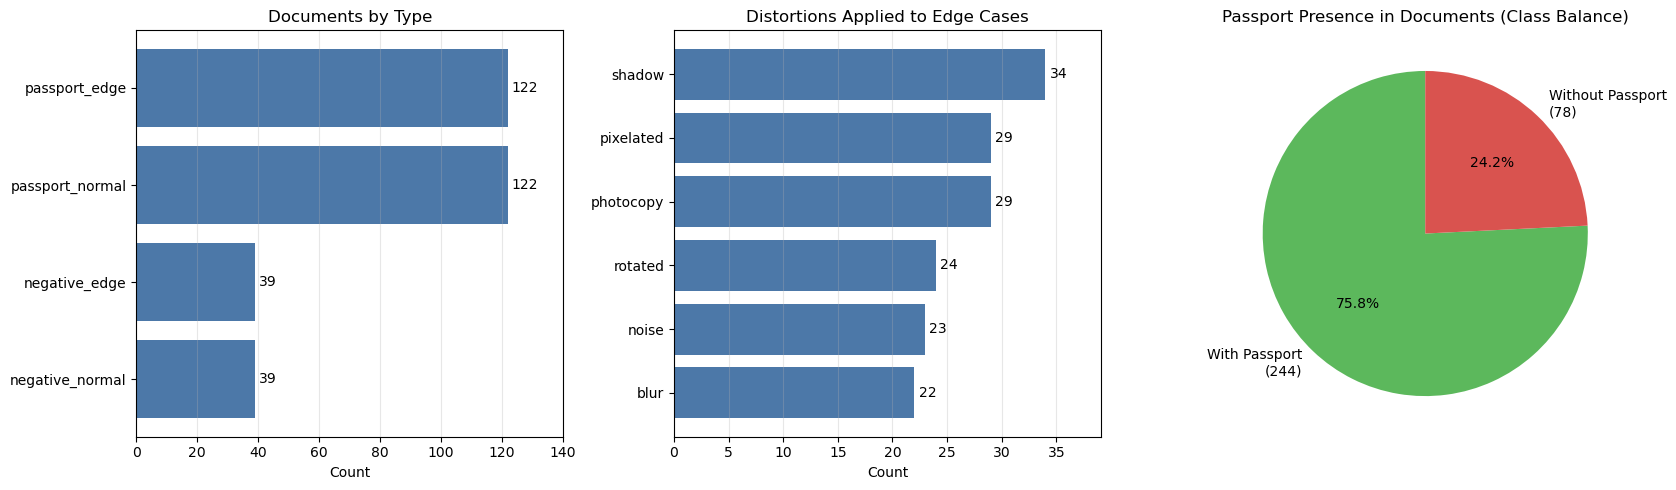

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- Chart 1: Documents by type ---
type_counts = doc_labels_df["doc_type"].value_counts().sort_values()
bars = axes[0].barh(type_counts.index, type_counts.values, color="#4c78a8")
axes[0].bar_label(bars, padding=3)
axes[0].set_title("Documents by Type")
axes[0].set_xlabel("Count")
axes[0].set_xlim(0, type_counts.max() * 1.15)
axes[0].grid(axis="x", alpha=0.3)

# --- Chart 2: Distortions applied to edge cases ---
distortions = (doc_labels_df[doc_labels_df["is_edge_case"] == 1]["distortion"]
               .value_counts().sort_values())
bars = axes[1].barh(distortions.index, distortions.values, color="#4c78a8")
axes[1].bar_label(bars, padding=3)
axes[1].set_title("Distortions Applied to Edge Cases")
axes[1].set_xlabel("Count")
axes[1].set_xlim(0, distortions.max() * 1.15)
axes[1].grid(axis="x", alpha=0.3)

# --- Chart 3: Class balance at document level ---
with_passport = int(doc_labels_df["contains_passport"].sum())
without = len(doc_labels_df) - with_passport

axes[2].pie(
    [with_passport, without],
    labels=[f"With Passport\n({with_passport})", f"Without Passport\n({without})"],
    colors=["#5cb85c", "#d9534f"],
    autopct="%1.1f%%",
    startangle=90,
)
axes[2].set_title("Passport Presence in Documents (Class Balance)")

plt.tight_layout()
plt.show()

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 24px 26px;">
<div style="width: 40px; height: 4px; background: #3498db; border-radius: 3px; margin-bottom: 12px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; font-size: 1.35em; font-weight: 700; color: #2c3e50;">המרת המסמכים לתמונות</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; line-height: 1.8; color: #2c3e50;">הרשת מקבלת תמונות ולא מסמכים, ולכן כל עמוד מרונדר לתמונה נפרדת. מסמכי Word מומרים תחילה ל-PDF, וזו גם הדרך שבה מתגלה מספר העמודים ובאיזה עמוד נמצאת התמונה — נתונים שלא היו ידועים בעת היצירה.</div>
<div style="direction: rtl !important; text-align: right !important; background: #f7fafc; border-right: 4px solid #3498db; border-radius: 8px; padding: 12px 16px; margin-bottom: 10px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 5px;">הגבלת עמודי הרקע</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">מכל מסמך נשמרים לכל היותר שני עמודים שאינם מכילים את התמונה. ללא הגבלה זו, כל דרכון היה מייצר עמוד חיובי אחד וכמה עמודים שליליים, והיחס בין המחלקות היה מוטה משמעותית.</div>
</div>
<div style="direction: rtl !important; text-align: right !important; background: #f7fafc; border-right: 4px solid #3498db; border-radius: 8px; padding: 12px 16px; margin-bottom: 10px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 5px;">סיווג עמודי הטקסט</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">עמוד מתוך מסמך דרכון שאינו מכיל את התמונה מסווג כ-<code style="direction: ltr; display: inline-block;">filler_text</code> ולא כדרכון, שכן מבחינת הרשת הוא עמוד טקסט לכל דבר. כך התיוג משקף את מה שנמצא בעמוד עצמו ולא את סוג המסמך שממנו הגיע.</div>
</div>
<div style="direction: rtl !important; text-align: right !important; background: #f7fafc; border-right: 4px solid #3498db; border-radius: 8px; padding: 12px 16px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 5px;">קובץ התיוגים ברמת העמוד</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">לכל תמונת עמוד נשמרת שורה בקובץ <code style="direction: ltr; display: inline-block;">page_labels.csv</code>, ובה התווית שהרשת תאומן עליה, מספר העמוד, המסמך שממנו הגיע, ובעמודים המכילים תמונה — גם השיבוש שהוחל ושם תמונת המקור.</div>
</div>
</div>

In [10]:
import shutil
from pathlib import Path
import pymupdf
from docx2pdf import convert
import pandas as pd
from tqdm.auto import tqdm

# --- Global paths and variables ---
PAGES_DIR = Path("data/pages")
TEMP_DIR = Path("data/_temp_pdf")
PAGE_LABELS_PATH = Path("data/page_labels.csv")
DOC_LABELS_PATH = Path("data/document_labels.csv")

# Resolution and page limits to prevent overload
PAGE_DPI = 150
MAX_NEGATIVE_PAGES_PER_DOC = 2


def find_image_page(pdf_document):
    """
    Return the 1-based first page holding an embedded image, or None.
    Reliable here because every other page is filler text only.
    """
    for page_number, page in enumerate(pdf_document, start=1):
        if page.get_images():
            return page_number
    return None


def convert_word_documents(doc_labels):
    """
    Convert all Word documents to PDF in one batch.
    Returns a mapping from filename to the resulting PDF path.
    """
    word_rows = doc_labels[doc_labels["format"] == "docx"]
    if word_rows.empty:
        return {}

    TEMP_DIR.mkdir(parents=True, exist_ok=True)
    for _, row in word_rows.iterrows():
        shutil.copy(row["path"], TEMP_DIR / row["filename"])

    print(f"Converting {len(word_rows)} Word documents to PDF...")
    convert(str(TEMP_DIR))

    return {
        row["filename"]: TEMP_DIR / f"{Path(row['filename']).stem}.pdf"
        for _, row in word_rows.iterrows()
    }


def render_pages(doc_labels):
    """Render each document to page images and build page-level labels."""
    word_pdfs = convert_word_documents(doc_labels)

    page_records = []
    resolved = []

    for _, row in tqdm(doc_labels.iterrows(), total=len(doc_labels), desc="Rendering"):
        pdf_path = word_pdfs.get(row["filename"], row["path"])
        if not Path(pdf_path).exists():
            print(f"  {row['filename']}: no PDF to render, skipping")
            continue

        try:
            document = pymupdf.open(pdf_path)
        except Exception as error:
            print(f"  {row['filename']}: could not open — {error}")
            continue

        page_count = len(document)
        image_page = row["image_page"]

        # Word pagination is only known now
        # Removed the text_only check since these documents are no longer generated
        if pd.isna(image_page):
            image_page = find_image_page(document)

        stem = Path(row["filename"]).stem
        negative_pages_saved = 0

        for page_number, page in enumerate(document, start=1):
            holds_image = (
                image_page is not None
                and not pd.isna(image_page)
                and page_number == image_page
            )

            # 1. Filter excess pages before rendering to save resources
            if not holds_image:
                if negative_pages_saved >= MAX_NEGATIVE_PAGES_PER_DOC:
                    continue
                negative_pages_saved += 1

            # 2. Correct document labeling for filler pages
            actual_doc_type = row["doc_type"]
            if not holds_image and "passport" in actual_doc_type:
                actual_doc_type = "filler_text"

            # 3. Create target directory and save the image
            target = PAGES_DIR / actual_doc_type
            target.mkdir(parents=True, exist_ok=True)
            
            page_name = f"{stem}_p{page_number:02d}.jpg"
            page.get_pixmap(dpi=PAGE_DPI).save(str(target / page_name))

            page_records.append({
                "page_name": page_name,
                "page_path": str(target / page_name),
                "document": row["filename"],
                "doc_type": actual_doc_type,
                "format": row["format"],
                "page_number": page_number,
                "doc_page_count": page_count,
                "contains_passport": int(holds_image and row["contains_passport"] == 1),
                "is_edge_case": int(holds_image and row["is_edge_case"] == 1),
                "distortion": row["distortion"] if holds_image else None,
                "source_image": row["source_image"] if holds_image else None,
            })

        document.close()

        resolved.append({
            "filename": row["filename"],
            "resolved_page_count": page_count,
            "resolved_image_page": image_page if image_page is not None else -1,
        })

    # Delete the temporary PDF directory
    shutil.rmtree(TEMP_DIR, ignore_errors=True)

    return pd.DataFrame(page_records), pd.DataFrame(resolved)


# --- Main logic execution ---

# Filter out any lingering 'text_only' documents from older runs to prevent errors
doc_labels_df = doc_labels_df[doc_labels_df["doc_type"] != "text_only"].copy()

page_labels_df, resolved_df = render_pages(doc_labels_df)

# Fold the recovered pagination back into the original DataFrame
doc_labels_df = doc_labels_df.merge(resolved_df, on="filename", how="left")
doc_labels_df["page_count"] = doc_labels_df["page_count"].fillna(doc_labels_df["resolved_page_count"])
doc_labels_df["image_page"] = doc_labels_df["image_page"].fillna(doc_labels_df["resolved_image_page"])
doc_labels_df = doc_labels_df.drop(columns=["resolved_page_count", "resolved_image_page"])

# Save (and overwrite) the CSV files
doc_labels_df.to_csv(DOC_LABELS_PATH, index=False)
page_labels_df.to_csv(PAGE_LABELS_PATH, index=False)

# Summary prints
print(f"\n{len(doc_labels_df)} documents -> {len(page_labels_df)} pages")
print(f"Page labels saved to {PAGE_LABELS_PATH}\n")
print("--- Document Types Distribution ---")
print(page_labels_df.groupby("doc_type").size().to_string())

positives = int(page_labels_df["contains_passport"].sum())
print(f"\nPages with a passport: {positives}")
print(f"Pages without:         {len(page_labels_df) - positives}")
print(f"Positive share:        {positives / len(page_labels_df):.1%}")

Converting 86 Word documents to PDF...


  0%|          | 0/86 [00:00<?, ?it/s]

Rendering:   0%|          | 0/322 [00:00<?, ?it/s]


322 documents -> 839 pages
Page labels saved to data\page_labels.csv

--- Document Types Distribution ---
doc_type
filler_text        386
negative_edge      105
negative_normal    104
passport_edge      122
passport_normal    122

Pages with a passport: 244
Pages without:         595
Positive share:        29.1%


<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 24px 26px;">
<div style="width: 40px; height: 4px; background: #3498db; border-radius: 3px; margin-bottom: 12px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; font-size: 1.35em; font-weight: 700; color: #2c3e50;">סיכום גרפי של המאגר לאחר ההמרה לתמונות</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0; line-height: 1.8; color: #2c3e50;">שני חתכים על תמונות העמוד שנוצרו בשלב הקודם — אלה שהרשת תקבל בפועל, ולא המסמכים שמהם הופקו. הראשון מציג את התפלגות העמודים לפי סוג, והשני את היחס בין עמודים המכילים דרכון לבין אלה שאינם מכילים, כלומר את האיזון בין המחלקות.</div>
</div>

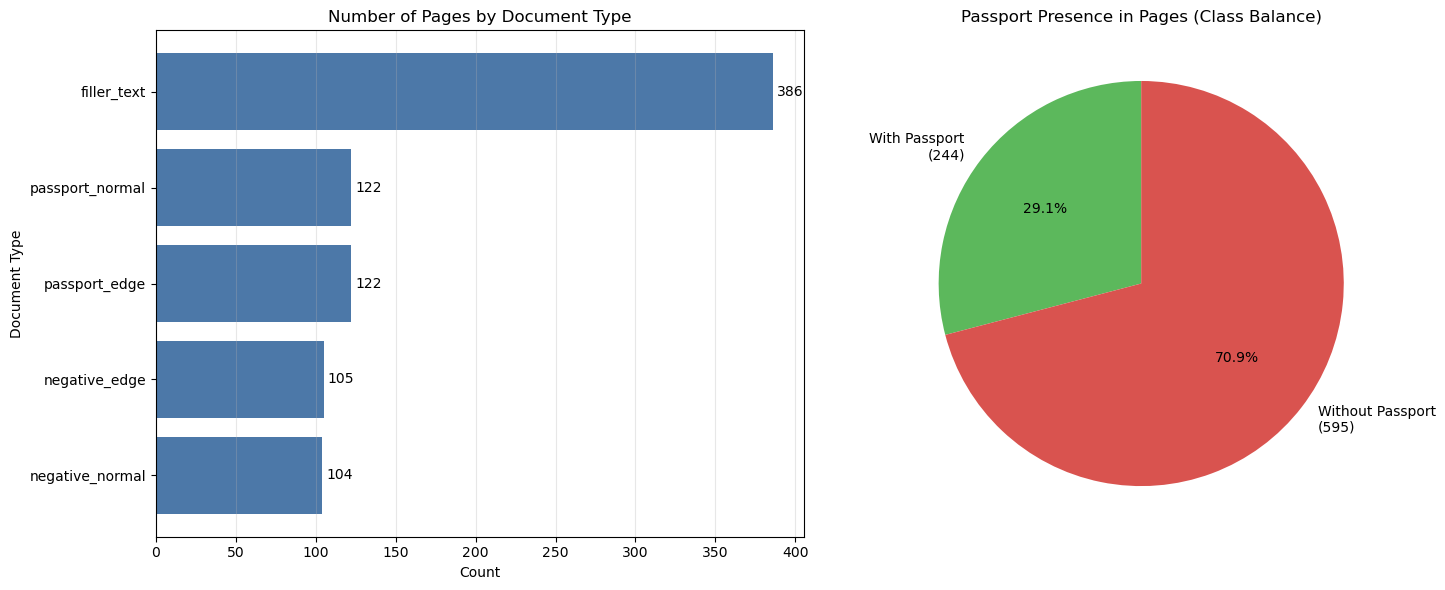

In [12]:
import matplotlib.pyplot as plt

positives = int(page_labels_df["contains_passport"].sum())
negatives = len(page_labels_df) - positives

# Set up the figure with two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Chart 1: Number of pages by document type ---
doc_type_counts = page_labels_df.groupby("doc_type").size().sort_values(ascending=True)
bars = axes[0].barh(doc_type_counts.index, doc_type_counts.values, color="#4c78a8")
axes[0].bar_label(bars, padding=3)
axes[0].set_title("Number of Pages by Document Type")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Document Type")
axes[0].grid(axis="x", alpha=0.3)

# --- Chart 2: Distribution of pages with vs. without a passport ---
sizes = [positives, negatives]
labels = [f'With Passport\n({positives})', f'Without Passport\n({negatives})']
colors = ["#5cb85c", "#d9534f"]

axes[1].pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
)
axes[1].set_title("Passport Presence in Pages (Class Balance)")

plt.tight_layout()
plt.show()

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #f7fafc; border: 1px solid #e1e8ed; border-right: 5px solid #3498db; border-radius: 12px; padding: 18px 22px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 5px;">ממצאים</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">מ-322 המסמכים הופקו 839 תמונות עמוד. 244 מהן מכילות דרכון — 122 בתנאים תקינים ו-122 עם שיבוש — כלומר 29% מהמאגר. יתר העמודים מתחלקים בין 386 עמודי טקסט, שהם עמודי הרקע של המסמכים, ו-209 עמודים המכילים קבלה.</div>
</div>